In [1]:
# 1. Import
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 2. Load data
data = pd.read_csv("daily-minimum-temperatures-in-me.csv")
temp = data['Daily minimum temperatures'].astype(float).values.reshape(-1, 1)

# 3. Scale
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp)

# 4. Create sequences
X, y = [], []
ts = 10
for i in range(len(temp_scaled)-ts):
    X.append(temp_scaled[i:i+ts])
    y.append(temp_scaled[i+ts])
X, y = np.array(X), np.array(y)

# 5. Build model
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(ts, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 6. Train
model.fit(X, y, epochs=20, batch_size=16)

# 7. Predict + plot
pred = model.predict(X)
pred = scaler.inverse_transform(pred)
real = scaler.inverse_transform(y)

plt.plot(real, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

ValueError: could not convert string to float: '?0.2'

Epoch 1/20


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0355  
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0137
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.0132
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.0136
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.0130
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - loss: 0.0129
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 0.0132
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - loss: 0.0139
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.0128
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 0.0142
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.0137
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.0123
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.0126
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.0120
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 0.0127
Ep

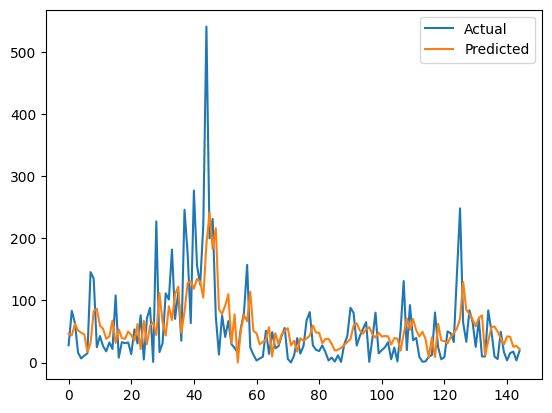

In [3]:
# 1. Import
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 2. Load CSV
data = pd.read_csv("Car_sales.csv")
sales = data['Sales_in_thousands'].astype(float).values.reshape(-1, 1)

# 3. Scale
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)

# 4. Create sequences (12 months)
X, y = [], []
ts = 12
for i in range(len(sales_scaled)-ts):
    X.append(sales_scaled[i:i+ts])
    y.append(sales_scaled[i+ts])
X, y = np.array(X), np.array(y)

# 5. Build RNN
model = Sequential([
    SimpleRNN(80, activation='tanh', input_shape=(ts, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 6. Train
model.fit(X, y, epochs=20, batch_size=8)

# 7. Predict + plot
pred = model.predict(X)
pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y)

plt.plot(actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
# 1. Import
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 2. Load CSV
data = pd.read_csv("stock_prices.csv")
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')

close = data['close'].values.reshape(-1, 1)

# 3. Scale
scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(close)

# 4. Create sequences
X, y = [], []
ts = 60
for i in range(len(close_scaled)-ts):
    X.append(close_scaled[i:i+ts])
    y.append(close_scaled[i+ts])
X, y = np.array(X), np.array(y)

# 5. RNN model
model = Sequential([
    SimpleRNN(80, activation='tanh', input_shape=(ts, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 6. Train
model.fit(X, y, epochs=10, batch_size=32)

# 7. Predict + plot
pred = model.predict(X)
pred = scaler.inverse_transform(pred)
real = scaler.inverse_transform(y)

plt.plot(data['date'][ts:], real, label='Actual')
plt.plot(data['date'][ts:], pred, label='Predicted')
plt.legend()
plt.show()

Epoch 1/10


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19344/19344 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.0023
Epoch 2/10
19344/19344 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.0023
Epoch 3/10
19344/19344 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.0023
Epoch 4/10
19344/19344 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.0023
Epoch 5/10
12279/19344 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0022